In [2]:
import kagglehub
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

c:\Users\Eng.Adel\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
import seaborn as sns
import cv2

In [4]:
TRAIN_DIR   = os.path.join(path, "Train")
TEST_DIR    = os.path.join(path, "Test")
TEST_CSV    = os.path.join(path, "Test.csv")

In [5]:
NUM_CLASSES = 43
CLASS_NAMES = {
    0:'Speed limit (20)',    1:'Speed limit (30)',   2:'Speed limit (50)',
    3:'Speed limit (60)',    4:'Speed limit (70)',   5:'Speed limit (80)',
    6:'End speed limit(80)', 7:'Speed limit (100)',  8:'Speed limit (120)',
    9:'No passing',         10:'No passing >3.5t',  11:'Right-of-way',
    12:'Priority road',     13:'Yield',              14:'Stop',
    15:'No vehicles',       16:'No >3.5t vehicles', 17:'No entry',
    18:'General caution',   19:'Danger curve left', 20:'Danger curve right',
    21:'Double curve',      22:'Bumpy road',         23:'Slippery road',
    24:'Road narrows',      25:'Road work',          26:'Traffic signals',
    27:'Pedestrians',       28:'Children crossing',  29:'Bicycles crossing',
    30:'Ice/snow',          31:'Wild animals',       32:'End speed+passing',
    33:'Turn right ahead',  34:'Turn left ahead',    35:'Ahead only',
    36:'Go straight/right', 37:'Go straight/left',   38:'Keep right',
    39:'Keep left',         40:'Roundabout',          41:'End no passing',
    42:'End no passing >3.5t'
}

In [6]:
print("Loading data from folder structure...")

train_paths = []
train_labels = []

# Loop through each class folder (0 to 42)
for class_id in tqdm(range(NUM_CLASSES), desc="Scanning class folders"):
    class_folder = os.path.join(TRAIN_DIR, str(class_id))
    if os.path.exists(class_folder):
        # Get all PNG files in the folder
        for img_file in os.listdir(class_folder):
            if img_file.endswith('.png'):
                img_path = os.path.join(class_folder, img_file)
                train_paths.append(img_path)
                train_labels.append(class_id)

print(f"\nTotal training images found: {len(train_paths):,}")

Loading data from folder structure...


Scanning class folders: 100%|██████████| 43/43 [00:00<00:00, 186.69it/s]


Total training images found: 39,209


In [7]:
# Check class distribution
class_counts = Counter(train_labels)
most_common = class_counts.most_common(1)[0]
least_common = min(class_counts.items(), key=lambda x: x[1])
print(f"Most common class     : {CLASS_NAMES[most_common[0]]} ({most_common[1]} imgs)")
print(f"Least common class    : {CLASS_NAMES[least_common[0]]} ({least_common[1]} imgs)")

Most common class     : Speed limit (50) (2250 imgs)
Least common class    : Speed limit (20) (210 imgs)


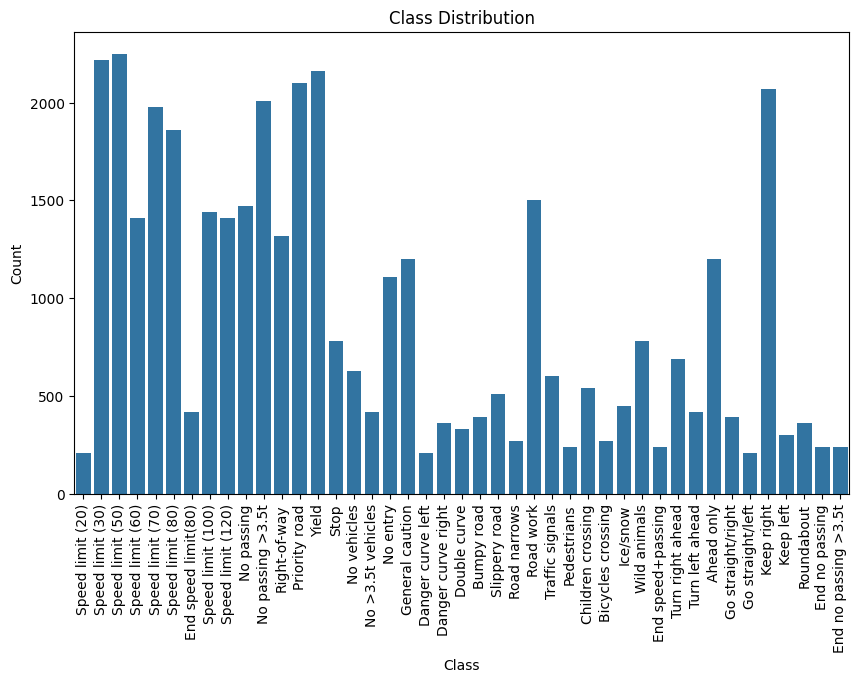

In [8]:
# visualize class balance
plt.figure(figsize=(10, 6))
sns.barplot(x=list(CLASS_NAMES.values()), y=list(class_counts.values()))
plt.xticks(rotation=90)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

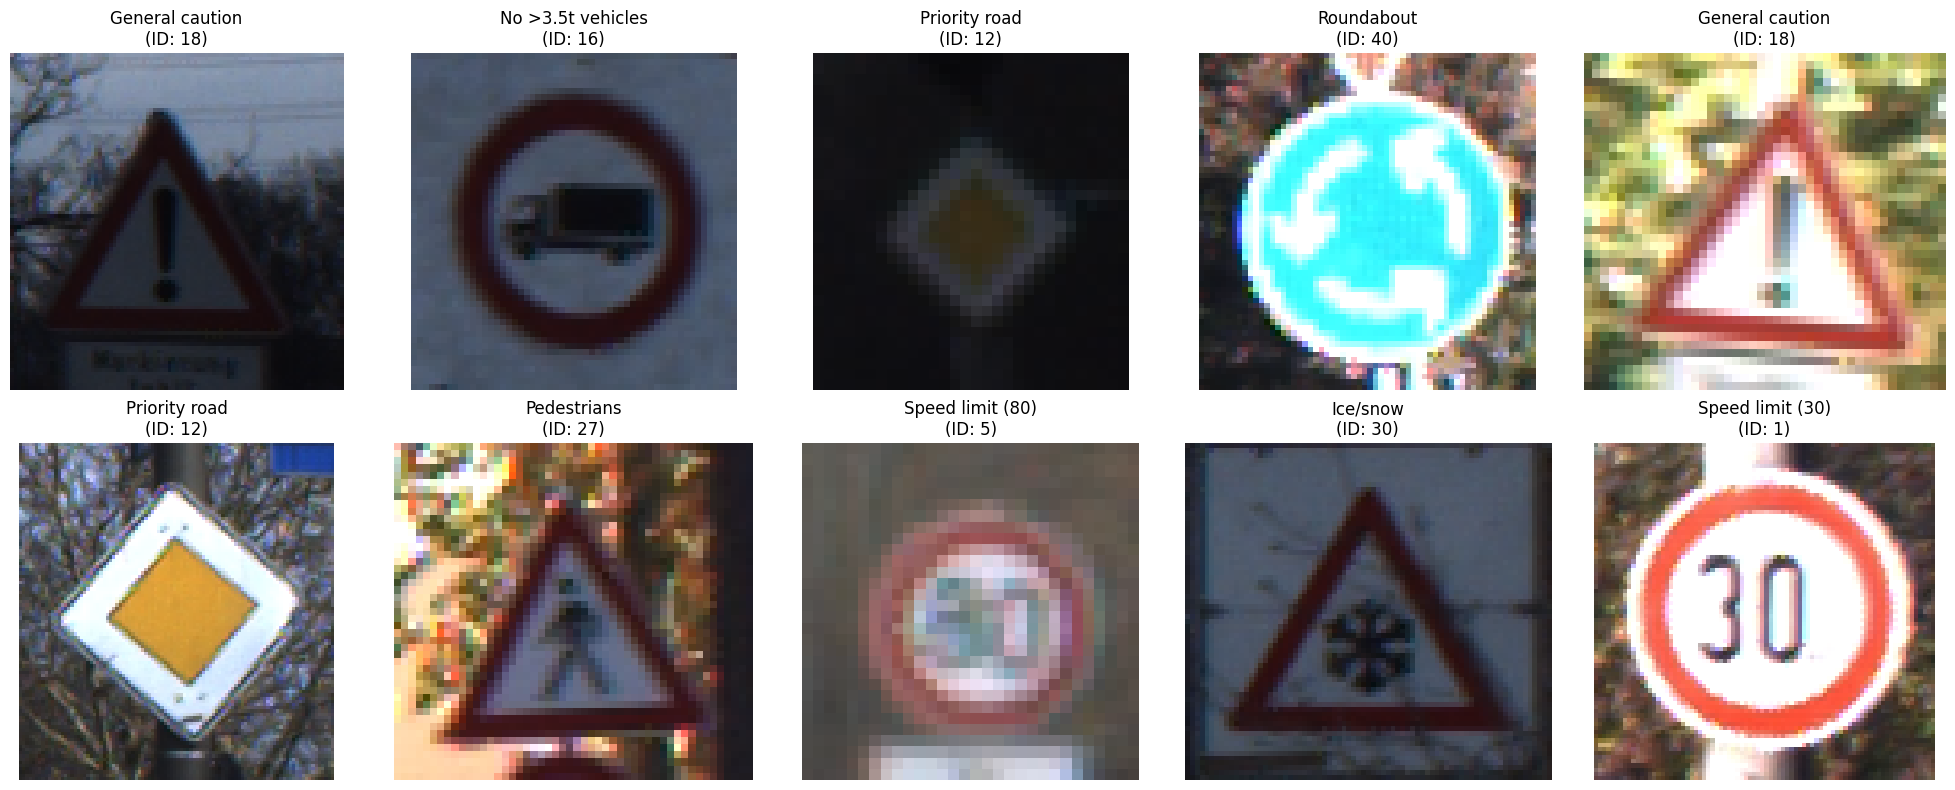

In [9]:
# show sample images
num_samples = 10
indices = np.random.choice(len(train_paths), num_samples, replace=False)

plt.figure(figsize=(20, 8))
for i, idx in enumerate(indices):
    img_path = train_paths[idx]
    label = train_labels[idx]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"{CLASS_NAMES[label]}\n(ID: {label})")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# pixel statistics

# mean and std per channel (RGB)
sums = np.zeros(3)
sum_sqs = np.zeros(3)
pixel_count = 0

# swample for speed (every 2nd image)
for img_path in tqdm(train_paths[::2], desc="Processing the potato in images"):
    img = cv2.imread(img_path)
    if img is None: continue

    # Convert BGR (OpenCV default) to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Normalize to [0, 1]
    img = img.astype(np.float32) / 255.0

    sums += np.sum(img, axis=(0, 1))
    sum_sqs += np.sum(img**2, axis=(0, 1))
    pixel_count += img.shape[0] * img.shape[1]

mean = sums / pixel_count
std = np.sqrt((sum_sqs / pixel_count) - (mean**2))

print(f"\nDataset Statistics (RGB):")
print(f"Mean: {mean}")
print(f"Std:  {std}")

Processing the potato in images: 100%|██████████| 19605/19605 [00:20<00:00, 938.18it/s] 


Dataset Statistics (RGB):
Mean: [0.37542943 0.34546535 0.35496636]
Std:  [0.29935843 0.29276565 0.29924224]


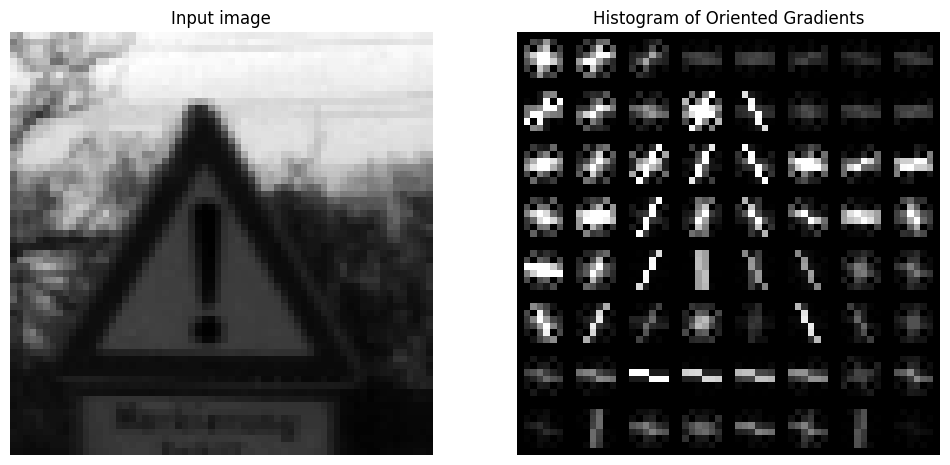

HOG feature vector shape: (512,)


In [11]:
from skimage.feature import hog
from skimage import exposure

# sample image to visualize HOG
img_path = train_paths[indices[0]]
img = cv2.imread(img_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_resized = cv2.resize(img_gray, (64, 64))

fd, hog_image = hog(img_resized, orientations=8, pixels_per_cell=(8, 8),
                    cells_per_block=(1, 1), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(img_resized, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

print(f'HOG feature vector shape: {fd.shape}')

In [12]:
from sklearn.decomposition import PCA
def extract_hog(img_path):
    # Load and preprocess
    img = cv2.imread(img_path)
    if img is None: return None
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, (64, 64))

    # Extract HOG
    fd = hog(img_resized, orientations=8, pixels_per_cell=(8, 8),
             cells_per_block=(1, 1), visualize=False)
    return fd

print(f"Extracting HOG features for {len(train_paths)} images...")
hog_features = []

# Extracting for all images
for path in tqdm(train_paths, desc="HOG Extraction"):
    features = extract_hog(path)
    if features is not None:
        hog_features.append(features)

# Features reduction using PCA
X_train = np.array(hog_features)
X_train_pca = PCA(n_components=128).fit_transform(X_train)
y_train = np.array(train_labels)

print(f"\nFeature extraction complete.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Extracting HOG features for 39209 images...


HOG Extraction: 100%|██████████| 39209/39209 [01:51<00:00, 352.36it/s]



Feature extraction complete.
X_train shape: (39209, 512)
y_train shape: (39209,)


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score

# Naive bayes before PCA
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)


print(f"Training Naive Bayes on {len(X_train_nb)} samples...")

nb = GaussianNB()
nb.fit(X_train_nb, y_train_nb)

# Prediction
y_pred_nb = nb.predict(X_test_nb)
y_prob_nb = nb.predict_proba(X_test_nb)

# Evaluation
print(f"\n Naive Bayes Validation Accuracy: {accuracy_score(y_test_nb, y_pred_nb):.4f}")
print("\nDetailed Naive Bayes Classification Report:")
print(classification_report(y_test_nb, y_pred_nb))
print("\nROC_AUC score:")
print(roc_auc_score(y_test_nb, y_prob_nb, multi_class= "ovr"))

Training Naive Bayes on 31367 samples...

 Naive Bayes Validation Accuracy: 0.8049

Detailed Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.74      0.41        42
           1       0.66      0.67      0.67       444
           2       0.71      0.56      0.62       450
           3       0.79      0.50      0.62       282
           4       0.86      0.71      0.78       396
           5       0.60      0.53      0.56       372
           6       0.99      0.88      0.93        84
           7       0.69      0.65      0.67       288
           8       0.46      0.64      0.53       282
           9       0.86      0.80      0.83       294
          10       0.77      0.86      0.82       402
          11       0.82      0.84      0.83       264
          12       0.95      1.00      0.97       420
          13       1.00      0.99      0.99       432
          14       0.99      0.87      0.93       156
       

In [14]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_train_pca, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Naive bayes after PCA
print(f"Training Naive Bayes on {len(X_train_nb)} samples...")

nb = GaussianNB()
nb.fit(X_train_nb, y_train_nb)

# Prediction
y_pred_nb = nb.predict(X_test_nb)
y_prob_nb = nb.predict_proba(X_test_nb)

# Evaluation
print(f"\n Naive Bayes Validation Accuracy: {accuracy_score(y_test_nb, y_pred_nb):.4f}")
print("\nDetailed Naive Bayes Classification Report:")
print(classification_report(y_test_nb, y_pred_nb))
print("\nROC_AUC score:")
print(roc_auc_score(y_test_nb, y_prob_nb, multi_class= "ovr"))

Training Naive Bayes on 31367 samples...

 Naive Bayes Validation Accuracy: 0.8458

Detailed Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.74      0.66        42
           1       0.71      0.77      0.74       444
           2       0.68      0.72      0.70       450
           3       0.79      0.72      0.75       282
           4       0.98      0.81      0.88       396
           5       0.63      0.71      0.67       372
           6       1.00      0.90      0.95        84
           7       0.81      0.77      0.79       288
           8       0.76      0.72      0.74       282
           9       0.87      0.87      0.87       294
          10       0.87      0.89      0.88       402
          11       0.75      0.74      0.74       264
          12       0.96      1.00      0.98       420
          13       1.00      0.99      0.99       432
          14       1.00      0.92      0.96       156
       

In [15]:
from sklearn.neighbors import KNeighborsClassifier

# KNN before PCA
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training KNN on {len(X_train_split)} samples...")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_split, y_train_split)

# Predict and evaluate
y_pred_knn = knn.predict(X_val_split)
y_prob_knn = knn.predict_proba(X_val_split)

print(f"\nKNN Validation Accuracy: {accuracy_score(y_val_split, y_pred_knn):.4f}")
print("\nDetailed KNN Classification Report:")
print(classification_report(y_val_split, y_pred_knn, target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)]))
print("\nROC_AUC score:")
print(roc_auc_score(y_val_split, y_prob_knn, multi_class= "ovr"))

Training KNN on 31367 samples...

KNN Validation Accuracy: 0.9580

Detailed KNN Classification Report:
                      precision    recall  f1-score   support

    Speed limit (20)       0.97      0.88      0.93        42
    Speed limit (30)       0.94      0.95      0.95       444
    Speed limit (50)       0.84      0.94      0.89       450
    Speed limit (60)       0.95      0.91      0.93       282
    Speed limit (70)       0.91      0.96      0.93       396
    Speed limit (80)       0.88      0.91      0.90       372
 End speed limit(80)       1.00      0.99      0.99        84
   Speed limit (100)       0.95      0.88      0.91       288
   Speed limit (120)       0.90      0.94      0.92       282
          No passing       0.98      0.98      0.98       294
    No passing >3.5t       0.98      0.94      0.96       402
        Right-of-way       0.97      0.97      0.97       264
       Priority road       0.99      1.00      1.00       420
               Yield       1

In [16]:
# KNN after PCA
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_pca, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training KNN on {len(X_train_split)} samples...")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_split, y_train_split)

# Predict and evaluate
y_pred_knn = knn.predict(X_val_split)
y_prob_knn = knn.predict_proba(X_val_split)

print(f"\nKNN Validation Accuracy: {accuracy_score(y_val_split, y_pred_knn):.4f}")
print("\nDetailed KNN Classification Report:")
print(classification_report(y_val_split, y_pred_knn, target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)]))
print("\nROC_AUC score:")
print(roc_auc_score(y_val_split, y_prob_knn, multi_class= "ovr"))

Training KNN on 31367 samples...

KNN Validation Accuracy: 0.9601

Detailed KNN Classification Report:
                      precision    recall  f1-score   support

    Speed limit (20)       0.97      0.83      0.90        42
    Speed limit (30)       0.93      0.94      0.94       444
    Speed limit (50)       0.88      0.94      0.91       450
    Speed limit (60)       0.92      0.91      0.91       282
    Speed limit (70)       0.92      0.96      0.94       396
    Speed limit (80)       0.89      0.90      0.89       372
 End speed limit(80)       1.00      0.98      0.99        84
   Speed limit (100)       0.95      0.90      0.92       288
   Speed limit (120)       0.93      0.95      0.94       282
          No passing       0.96      0.99      0.98       294
    No passing >3.5t       0.99      0.95      0.97       402
        Right-of-way       0.95      0.96      0.95       264
       Priority road       0.99      1.00      1.00       420
               Yield       1

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# Stratify ensures the class balance is maintained in both sets
X_train_ens, X_val_ens, y_train_ens, y_val_ens = train_test_split(
    X_train_pca, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Data split complete.")
print(f"Training samples: {X_train_ens.shape[0]} | Validation samples: {X_val_ens.shape[0]}")

Data split complete.
Training samples: 31367 | Validation samples: 7842


In [18]:
print("Training Random Forest (Bagging)...")

# Initialize and train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_ens, y_train_ens)

# Predict
y_pred_rf = rf_model.predict(X_val_ens)
y_prob_rf = rf_model.predict_proba(X_val_ens)

print(f"RF Validation Accuracy: {accuracy_score(y_val_ens, y_pred_rf):.4f}")

Training Random Forest (Bagging)...
RF Validation Accuracy: 0.8685


In [19]:
print("Training XGBoost (Boosting)...")

# Initialize and train
# 'mlogloss' is the standard loss function for multi-class classification
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, 
                          use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_ens, y_train_ens)

# Predict
y_pred_xgb = xgb_model.predict(X_val_ens)
y_prob_xgb = xgb_model.predict_proba(X_val_ens)

print(f"XGBoost Validation Accuracy: {accuracy_score(y_val_ens, y_pred_xgb):.4f}")

Training XGBoost (Boosting)...


c:\Users\Eng.Adel\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:34:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Validation Accuracy: 0.8884


In [20]:
# ensemble report
print("\n" + "="*30)
print("RANDOM FOREST REPORT")
print("="*30)
print(classification_report(y_val_ens, y_pred_rf))

print("\n" + "="*30)
print("XGBOOST REPORT")
print("="*30)
print(classification_report(y_val_ens, y_pred_xgb))

# Final Comparison Table
summary = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_val_ens, y_pred_rf), accuracy_score(y_val_ens, y_pred_xgb)],
    'ROC-AUC': [roc_auc_score(y_val_ens, y_prob_rf, multi_class='ovr'), 
                roc_auc_score(y_val_ens, y_prob_xgb, multi_class='ovr')]
})

print("\nFinal Ensemble Comparison:")
print(summary)


RANDOM FOREST REPORT
              precision    recall  f1-score   support

           0       1.00      0.26      0.42        42
           1       0.76      0.87      0.81       444
           2       0.69      0.85      0.76       450
           3       0.86      0.74      0.80       282
           4       0.87      0.87      0.87       396
           5       0.75      0.72      0.74       372
           6       0.97      0.93      0.95        84
           7       0.84      0.81      0.82       288
           8       0.87      0.74      0.80       282
           9       0.84      0.91      0.87       294
          10       0.89      0.95      0.92       402
          11       0.64      0.93      0.76       264
          12       0.98      0.99      0.99       420
          13       0.98      1.00      0.99       432
          14       1.00      0.92      0.96       156
          15       1.00      0.75      0.86       126
          16       1.00      0.96      0.98        84
     